# 03 · אמידת מצב סטוכסטית ומסנן קלמן
**מבוסס על:** *Estimation in Information Fusion* — W. Dale Blair, FUSION Boot Camp 2026, חלק ב'.

במחברת 02 אמדנו פרמטר **נייח**. כעת המצב **מתפתח בזמן** (מיקום, מהירות, תאוצה). 
**מסנן קלמן הוא 'סוס העבודה' של מעקב מטרות** ונותן את אומד ה-MMSE כאשר השגיאות גאוסיאניות.

## א. המודל בזמן בדיד
$$x_{k+1} = F_k\,x_k + G_k\,v_k, \qquad z_k = H_k\,x_k + w_k$$

* $x_k$ — וקטור המצב (מיקום, מהירות, ואולי תאוצה).
* $v_k\sim\mathcal{N}(0,Q_k)$ — **רעש תהליך** (process / plant noise).
* $w_k\sim\mathcal{N}(0,R_k)$ — רעש מדידה.
* $F$ — מטריצת מעבר (אילוץ התנועה הקינמטי); $H$ — קושר מדידות למצב (צורות לא-לינאריות → EKF, מחברת 04).

**רעש התהליך הוא ההבדל המהותי** בין מסנן קלמן (אמידת מצב סטוכסטית) לבין LSE (אמידה פרמטרית): 
הוא מבטא אי-ודאות בהתפתחות/מידול המצב מצעד $k$ ל-$k{+}1$, אפס-תוחלת ולבן.

## ב. גזירת מסנן קלמן — predictor / corrector
המסנן הוא אלגוריתם **חזאי–מתקן (predictor-corrector)**:

**עדכון זמן (Time Update / Predict):**
$$\hat{x}_{k|k-1}=F_{k-1}\hat{x}_{k-1|k-1}, \qquad P_{k|k-1}=F_{k-1}P_{k-1|k-1}F_{k-1}^{T}+G_{k-1}Q_{k-1}G_{k-1}^{T}$$

**עדכון מדידה (Measurement Update / Correct):**
$$S_k = H_kP_{k|k-1}H_k^{T}+R_k \quad(\text{שונות החדשה / innovation})$$
$$K_k = P_{k|k-1}H_k^{T}S_k^{-1} \quad(\text{Kalman gain})$$
$$\hat{x}_{k|k}=\hat{x}_{k|k-1}+K_k\,[\,z_k-H_k\hat{x}_{k|k-1}\,]$$
$$P_{k|k}=(I-K_kH_k)\,P_{k|k-1}$$

ה-gain $K_k$ מאזן בין אמון במודל (predict) לאמון במדידה: $R$ גדול → $K$ קטן (מאמינים למודל), ולהפך.

> **אזהרת השקופית:** מסנן קלמן מניח **שיוך מדידה-למסלול מושלם** (perfect measurement-to-track association) — 
> זו בדיוק הנקודה שבה נכנס שיוך נתונים (הרצאת Meyer).

## ג. מודל ה-NCV ורעש התהליך (DWNA מול CWNA)
**Nearly Constant Velocity (NCV)** — המודל הנפוץ ביותר במעקב. וקטור המצב $x=[p,\dot p]^T$:

$$F=\begin{bmatrix}1 & T\\ 0 & 1\end{bmatrix},\quad H=\begin{bmatrix}1 & 0\end{bmatrix}$$

שתי דרכים נפוצות למדל את רעש התהליך (תאוצה לא-מתוכננת בשונות $\sigma_a^2$ או PSD $q$):

**DWNA — Discrete White Noise Acceleration:**
$$Q = \Gamma\Gamma^{T}\sigma_a^2,\quad \Gamma=\begin{bmatrix}T^2/2\\ T\end{bmatrix} \Rightarrow Q=\sigma_a^2\begin{bmatrix}T^4/4 & T^3/2\\ T^3/2 & T^2\end{bmatrix}$$

**CWNA — Continuous White Noise Acceleration:**
$$Q = q\begin{bmatrix}T^3/3 & T^2/2\\ T^2/2 & T\end{bmatrix}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(7)

def ncv_matrices(T, kind='DWNA', sigma_a=1.0):
    F = np.array([[1, T],[0, 1.0]])
    H = np.array([[1.0, 0.0]])
    if kind == 'DWNA':
        G = np.array([[T**2/2],[T]])
        Q = (G @ G.T) * sigma_a**2
    else:  # CWNA
        Q = sigma_a**2 * np.array([[T**3/3, T**2/2],[T**2/2, T]])
    return F, H, Q

class KalmanFilter:
    def __init__(self, F, H, Q, R, x0, P0):
        self.F,self.H,self.Q,self.R = map(np.atleast_2d,(F,H,Q,R))
        self.x = np.asarray(x0,float).reshape(-1,1)
        self.P = np.atleast_2d(P0).astype(float)
    def predict(self):
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q
        return self.x.ravel()
    def update(self, z):
        z = np.atleast_2d(np.asarray(z,float).reshape(-1,1))
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        y = z - self.H @ self.x
        self.x = self.x + K @ y
        I = np.eye(self.P.shape[0])
        self.P = (I - K @ self.H) @ self.P
        return self.x.ravel(), y.item(), S.item()

print('Kalman filter + NCV models defined.')

Kalman filter + NCV models defined.


## ד. סימולציה: מעקב NCV אחר מטרה במהירות קבועה
מטרה נעה במהירות קבועה; החיישן מודד **רק מיקום** עם רעש $\sigma_w$. 
המסנן אומד מיקום ו**מהירות** (שאינה נמדדת ישירות) — זהו כוחה של אמידת המצב.

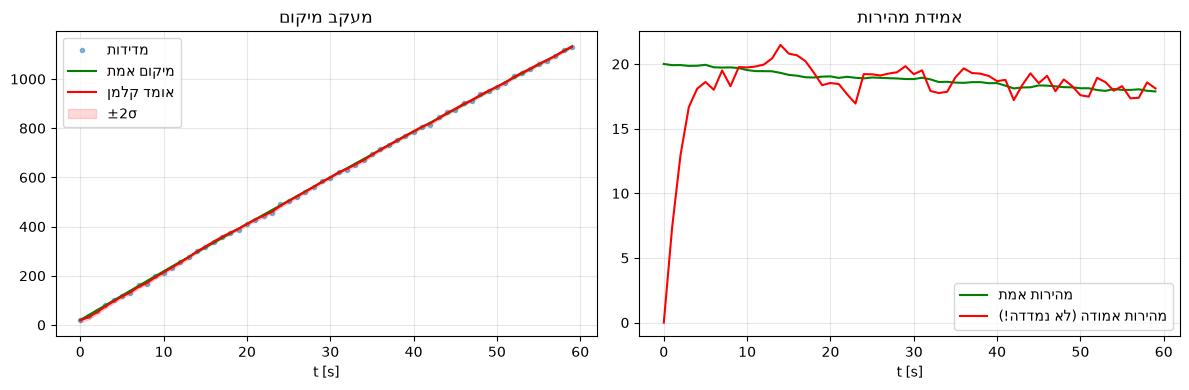

RMSE מיקום: גולמי=4.35 m, מסונן=3.41 m


In [2]:
T, steps = 1.0, 60
sigma_w = 5.0          # רעש מדידה [m]
sigma_a_true = 0.1     # תמרון אמיתי קטן
F, H, _ = ncv_matrices(T)
Qsim = ncv_matrices(T, 'DWNA', sigma_a_true)[2]

# יצירת מסלול אמת
x = np.array([[0.],[20.]])   # מיקום 0, מהירות 20 m/s
truth, meas = [], []
Lq = np.linalg.cholesky(Qsim + 1e-12*np.eye(2))
for _ in range(steps):
    x = F @ x + Lq @ rng.standard_normal((2,1))
    truth.append(x.ravel().copy())
    meas.append((H @ x).item() + sigma_w*rng.standard_normal())
truth = np.array(truth); meas = np.array(meas)

# הרצת המסנן
Fk, Hk, Qk = ncv_matrices(T, 'DWNA', sigma_a=1.0)
kf = KalmanFilter(Fk, Hk, Qk, R=sigma_w**2, x0=[meas[0],0], P0=np.diag([sigma_w**2,100]))
est_pos, est_vel, pos_std = [], [], []
for z in meas:
    kf.predict()
    xe,_,_ = kf.update(z)
    est_pos.append(xe[0]); est_vel.append(xe[1]); pos_std.append(np.sqrt(kf.P[0,0]))
est_pos,est_vel,pos_std = map(np.array,(est_pos,est_vel,pos_std))

t = np.arange(steps)*T
fig, ax = plt.subplots(1,2,figsize=(12,4))
ax[0].plot(t, meas,'.',alpha=.5,label='מדידות')
ax[0].plot(t, truth[:,0],'g',label='מיקום אמת')
ax[0].plot(t, est_pos,'r',label='אומד קלמן')
ax[0].fill_between(t, est_pos-2*pos_std, est_pos+2*pos_std, color='r', alpha=.15, label='±2σ')
ax[0].set_title('מעקב מיקום'); ax[0].legend(); ax[0].grid(alpha=.3); ax[0].set_xlabel('t [s]')
ax[1].plot(t, truth[:,1],'g',label='מהירות אמת')
ax[1].plot(t, est_vel,'r',label='מהירות אמודה (לא נמדדה!)')
ax[1].set_title('אמידת מהירות'); ax[1].legend(); ax[1].grid(alpha=.3); ax[1].set_xlabel('t [s]')
plt.tight_layout(); plt.show()
print(f'RMSE מיקום: גולמי={np.sqrt(np.mean((meas-truth[:,0])**2)):.2f} m,'
      f' מסונן={np.sqrt(np.mean((est_pos-truth[:,0])**2)):.2f} m')

## ה. תרומת רעש התהליך והתכנסות ה-gain
כאשר $Q$ קבוע ו-$R$ קבוע, מטריצת השונות $P$ וה-gain $K$ מתכנסים למצב יציב (steady state). 
ככל ש-$Q$ קטן יותר — המסנן 'מאמין' יותר למודל, ה-gain קטן והאומד חלק אך איטי לתמרונים (נושא מחברת 04).

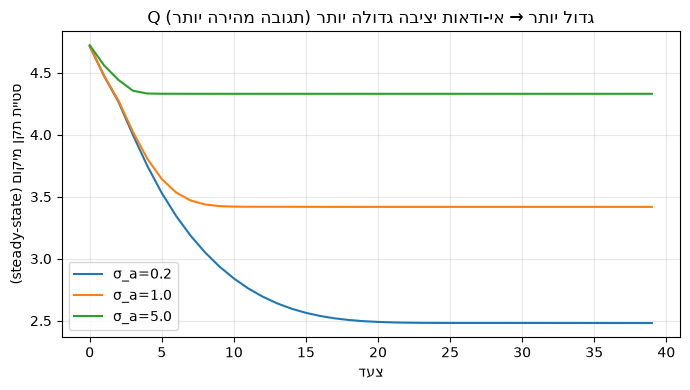

In [3]:
# התכנסות gain ו-position std עבור ערכי sigma_a שונים
plt.figure(figsize=(7,4))
for sa in [0.2, 1.0, 5.0]:
    Fk,Hk,Qk = ncv_matrices(T,'DWNA',sigma_a=sa)
    kf = KalmanFilter(Fk,Hk,Qk,R=sigma_w**2,x0=[0,0],P0=np.diag([100.,100.]))
    stds=[]
    for _ in range(40):
        kf.predict(); kf.update(0.0); stds.append(np.sqrt(kf.P[0,0]))
    plt.plot(stds, label=f'σ_a={sa}')
plt.xlabel('צעד'); plt.ylabel('סטיית תקן מיקום (steady-state)')
plt.title('Q גדול יותר → אי-ודאות יציבה גדולה יותר (תגובה מהירה יותר)')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## ו. בדיקת עקביות (NEES / innovation)
מסנן 'עקבי' (consistent) מייצר חדשות (innovations) שמתאימות לשונות $S_k$ שהוא עצמו מנבא. 
מדד נפוץ: ה-innovation המנורמל $y_k/\sqrt{S_k}$ אמור להתפלג כ-$\mathcal{N}(0,1)$.

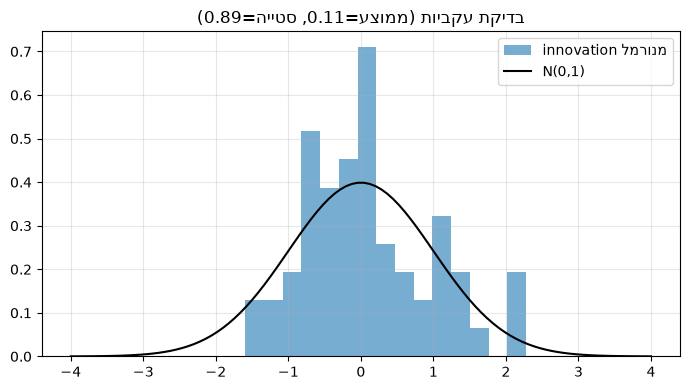

In [4]:
kf = KalmanFilter(Fk:=ncv_matrices(T,'DWNA',1.0)[0], ncv_matrices(T)[1],
                  ncv_matrices(T,'DWNA',1.0)[2], R=sigma_w**2,
                  x0=[meas[0],0], P0=np.diag([sigma_w**2,100]))
norm_innov=[]
for z in meas:
    kf.predict(); _,y,S = kf.update(z); norm_innov.append(y/np.sqrt(S))
norm_innov=np.array(norm_innov)
plt.figure(figsize=(7,4))
plt.hist(norm_innov, bins=15, density=True, alpha=.6, label='innovation מנורמל')
xx=np.linspace(-4,4,100); plt.plot(xx, np.exp(-xx**2/2)/np.sqrt(2*np.pi),'k',label='N(0,1)')
plt.title(f'בדיקת עקביות (ממוצע={norm_innov.mean():.2f}, סטייה={norm_innov.std():.2f})')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## סיכום
* **מסנן קלמן = predictor–corrector**; נותן MMSE תחת לינאריות+גאוסיאניות.
* **רעש התהליך** ($Q$, בצורת DWNA/CWNA) מבדיל אמידת מצב מאמידה פרמטרית, ושולט באיזון מודל↔מדידה.
* מודל **NCV** אומד מהירות גם כשמודדים רק מיקום, ומקטין משמעותית את שגיאת המיקום מול המדידה הגולמית.
* המסנן מניח **שיוך מדידה מושלם** ומודל **יחיד** — שתי הנחות שמחברת 04 מרפה (תמרון, IMM, אי-לינאריות).